# Machine Learning Lab - Experiment 4

## Support Vector Machine - Spam Email Classification

### Aim

To Classify SMS messages as spam or legitimate using an SVM classifier.

In [1]:
# ------------------------------------------------------------
# 1. Import required libraries
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# ------------------------------------------------------------
# 2. Upload the CSV file
# ------------------------------------------------------------

uploaded = files.upload()

Saving spam.csv to spam.csv


In [3]:
# ------------------------------------------------------------
# 3. Read the CSV file
# ------------------------------------------------------------

df = pd.read_csv("spam.csv", encoding="latin-1")

print("First 5 rows:")
print(df.head())

print("\nDataset shape:")
print(df.shape)

First 5 rows:
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  

Dataset shape:
(5572, 5)


In [4]:
# ------------------------------------------------------------
# 4. Select the required columns
# ------------------------------------------------------------

# Standard SMS Spam Collection:
# v1 = label
# v2 = message

data = df[["v1", "v2"]].copy()

data.columns = ["Spam", "Message"]

In [5]:
# ------------------------------------------------------------
# 5. Convert spam/ham into numerical values
# ------------------------------------------------------------

data["Spam"] = data["Spam"].map({
    "ham": 0,
    "spam": 1
})

# Remove missing values
data = data.dropna()

# Remove duplicate messages
data = data.drop_duplicates()


print("\nCleaned data:")
print(data.head())


Cleaned data:
   Spam                                            Message
0     0  Go until jurong point, crazy.. Available only ...
1     0                      Ok lar... Joking wif u oni...
2     1  Free entry in 2 a wkly comp to win FA Cup fina...
3     0  U dun say so early hor... U c already then say...
4     0  Nah I don't think he goes to usf, he lives aro...


In [6]:
# ------------------------------------------------------------
# 6. Create Word Frequency feature
# ------------------------------------------------------------

data["Word_Frequency"] = data["Message"].apply(
    lambda x: len(str(x).split())
)

In [7]:
# ------------------------------------------------------------
# 7. Create Message Length feature
# ------------------------------------------------------------

data["Message_Length"] = data["Message"].apply(
    lambda x: len(str(x))
)


print("\nFeatures:")
print(data[["Word_Frequency", "Message_Length", "Spam"]].head())


Features:
   Word_Frequency  Message_Length  Spam
0              20             111     0
1               6              29     0
2              28             155     1
3              11              49     0
4              13              61     0


In [8]:
# ------------------------------------------------------------
# 8. Select features and target
# ------------------------------------------------------------

X = data[["Word_Frequency", "Message_Length"]]

y = data["Spam"]

In [9]:
# ------------------------------------------------------------
# 9. Split data into training and testing sets
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [10]:
# ------------------------------------------------------------
# 10. Standardize the features
# ------------------------------------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [11]:
# ------------------------------------------------------------
# 11. Create SVM classifier
# ------------------------------------------------------------

classifier = SVC(
    kernel="linear",
    C=1.0
)


In [12]:
# ------------------------------------------------------------
# 12. Train the SVM model
# ------------------------------------------------------------

classifier.fit(X_train, y_train)

SVC(kernel='linear')

In [13]:
# ------------------------------------------------------------
# 13. Make predictions
# ------------------------------------------------------------

y_pred = classifier.predict(X_test)

In [14]:
# ------------------------------------------------------------
# 14. Calculate accuracy
# ------------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\n----- Model Performance -----")

print("Accuracy:", round(accuracy * 100, 2), "%")


----- Model Performance -----
Accuracy: 89.75 %


In [15]:
# ------------------------------------------------------------
# 15. Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[887  16]
 [ 90  41]]


In [17]:
# ------------------------------------------------------------
# 16. Classification Report
# ------------------------------------------------------------

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Ham", "Spam"]
    )
)


Classification Report:
              precision    recall  f1-score   support

         Ham       0.91      0.98      0.94       903
        Spam       0.72      0.31      0.44       131

    accuracy                           0.90      1034
   macro avg       0.81      0.65      0.69      1034
weighted avg       0.88      0.90      0.88      1034



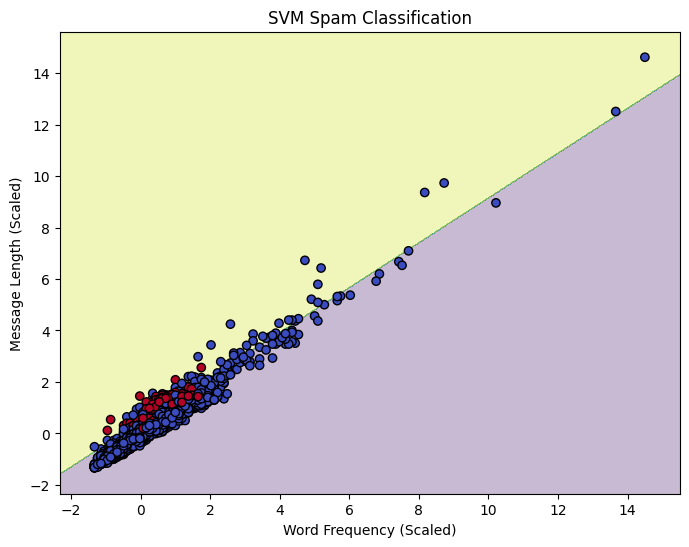

In [18]:
# ------------------------------------------------------------
# 17. Visualize SVM Decision Boundary
# ------------------------------------------------------------

X_all_scaled = scaler.transform(X)

x_min = X_all_scaled[:, 0].min() - 1
x_max = X_all_scaled[:, 0].max() + 1

y_min = X_all_scaled[:, 1].min() - 1
y_max = X_all_scaled[:, 1].max() + 1


xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)


Z = classifier.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)


plt.figure(figsize=(8, 6))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.3
)

plt.scatter(
    X_all_scaled[:, 0],
    X_all_scaled[:, 1],
    c=y,
    cmap="coolwarm",
    edgecolors="k"
)

plt.title("SVM Spam Classification")
plt.xlabel("Word Frequency (Scaled)")
plt.ylabel("Message Length (Scaled)")

plt.show()

In [19]:
# ------------------------------------------------------------
# 18. Predict new messages
# ------------------------------------------------------------

new_messages = [
    "Congratulations! You have won a free prize. Call now!",
    "Hey, are we meeting at college tomorrow?"
]


# Calculate features for new messages

new_word_frequency = [
    len(message.split())
    for message in new_messages
]

new_message_length = [
    len(message)
    for message in new_messages
]


new_data = pd.DataFrame({
    "Word_Frequency": new_word_frequency,
    "Message_Length": new_message_length
})


# Scale new data

new_data_scaled = scaler.transform(new_data)


# Predict

predictions = classifier.predict(new_data_scaled)


# Display predictions

print("\n----- New Message Predictions -----")

for message, prediction in zip(new_messages, predictions):

    if prediction == 1:
        result = "SPAM"
    else:
        result = "HAM"

    print(result, "->", message)


----- New Message Predictions -----
HAM -> Congratulations! You have won a free prize. Call now!
HAM -> Hey, are we meeting at college tomorrow?
